
# 🧪 Proyecto: Detección automática de críticas negativas (IMDB) — *ilm Junky Union*

**Objetivo:** entrenar y evaluar un clasificador de sentimiento para reseñas de películas de IMDB que alcance **F1 ≥ 0.85** para la clase negativa (`pos=0`).  

**Checklist del proyecto**  
1. Carga de datos (`imdb_reviews.tsv`).  
2. Preprocesamiento básico del texto y EDA (incluye revisión de desequilibrio de clases).  
3. Transformación del texto a vectores (TF–IDF variantes + opcional BERT pequeño sobre una muestra).  
4. Entrenamiento de **al menos 3 modelos** (Logistic Regression, Linear SVM, Naive Bayes/SGD).  
5. Evaluación en *train/valid* y *test* con **F1** (macro y por clase).  
6. Escríbe tus propias reseñas y clasifícalas con todos los modelos.  
7. Compara resultados entre modelos y explica diferencias.  
8. Muestra hallazgos y conclusiones.

> **Nota sobre BERT:** por rendimiento en CPU, BERT se deja como **opcional** sobre una muestra pequeña. Si lo activas, ejecuta solo con unos pocos cientos de ejemplos y, ojalá, en GPU.


In [5]:

# === Configuración e imports ===
import os
from pathlib import Path
import re
import html
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score, confusion_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.naive_bayes import ComplementNB
from sklearn.svm import LinearSVC
from sklearn.utils.class_weight import compute_class_weight

DATA_PATH = Path('imdb_reviews.tsv')  # <-- cambia si ejecutas local
RANDOM_STATE = 42

print('Ruta esperada de datos:', DATA_PATH)
print('Existe el archivo?', DATA_PATH.exists())


Ruta esperada de datos: imdb_reviews.tsv
Existe el archivo? True


In [6]:

# === 1) Carga de datos ===
# El dataset debe llamarse imdb_reviews.tsv y tener, mínimo:
#   - review: texto de la reseña
#   - pos: target binario (0=negativo, 1=positivo)
#   - ds_part: 'train'/'test' o 'entrenamiento'/'prueba'
#
# Si no existe el archivo, mostramos una guía.
if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"No se encuentra {DATA_PATH}.\n"
        "➡️ Sube/ubica 'imdb_reviews.tsv' en esa ruta o cambia DATA_PATH.\n"
        "El TSV debe incluir columnas: review, pos, ds_part."
    )

df = pd.read_csv(DATA_PATH, sep='\t')
print(df.head(3))
print(df.columns.tolist())
print('Forma:', df.shape)


      tconst title_type primary_title original_title  start_year end_year  \
0  tt0068152      movie             $              $        1971       \N   
1  tt0068152      movie             $              $        1971       \N   
2  tt0313150      short          '15'           '15'        2002       \N   

  runtime_minutes  is_adult              genres  average_rating   votes  \
0             121         0  Comedy,Crime,Drama             6.3  2218.0   
1             121         0  Comedy,Crime,Drama             6.3  2218.0   
2              25         0  Comedy,Drama,Short             6.3   184.0   

                                              review  rating   sp  pos  \
0  The pakage implies that Warren Beatty and Gold...       1  neg    0   
1  How the hell did they get this made?! Presenti...       1  neg    0   
2  There is no real story the film seems more lik...       3  neg    0   

  ds_part   idx  
0   train  8335  
1   train  8336  
2    test  2489  
['tconst', 'title_typ

In [7]:

# Normalizamos posibles etiquetas de ds_part
df['ds_part'] = df['ds_part'].astype(str).str.lower().str.strip()
df['ds_part'] = df['ds_part'].replace({'entrenamiento': 'train',
                                       'training': 'train',
                                       'prueba': 'test',
                                       'testing': 'test'})

# Forzamos tipos
df['pos'] = df['pos'].astype(int)
assert set(df['pos'].unique()).issubset({0,1}), "La columna 'pos' debe ser 0/1"


In [9]:

# === 2) Preprocesamiento básico de texto ===
# Limpiador sencillo: desescape HTML, quita tags, baja a minúsculas, espacios múltiples.
TAG_RE = re.compile(r"<[^>]+>")

def clean_text(s: str) -> str:
    if not isinstance(s, str):
        s = str(s)
    s = html.unescape(s)               # &amp; -> &
    s = TAG_RE.sub(" ", s)             # quita etiquetas HTML
    s = s.replace("\n", " ").replace("\r", " ")
    s = re.sub(r"\s+", " ", s)         # colapsa espacios
    return s.strip().lower()

df['review_clean'] = df['review'].map(clean_text)
df[['review', 'review_clean']].head(3)


,review,review_clean
0,The pakage implies that Warren Beatty and Gold...,the pakage implies that warren beatty and gold...
1,How the hell did they get this made?! Presenti...,how the hell did they get this made?! presenti...
2,There is no real story the film seems more lik...,there is no real story the film seems more lik...


Descripción longitud (caracteres):
count    47331.00000
mean      1289.97695
std        974.94370
min         32.00000
25%        691.00000
50%        957.00000
75%       1566.00000
max      13593.00000
Name: len_char, dtype: float64

Descripción longitud (tokens):
count    47331.000000
mean       229.428261
std        170.075283
min          4.000000
25%        125.500000
50%        172.000000
75%        278.000000
max       2459.000000
Name: len_tokens, dtype: float64

Distribución de clases (pos=1 es positivo):
pos
0    23715
1    23616
Name: count, dtype: int64


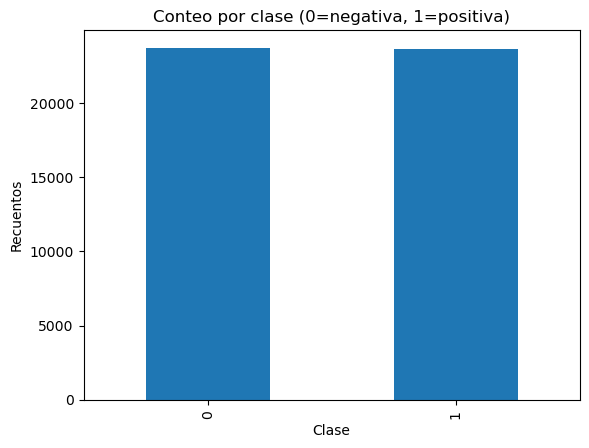

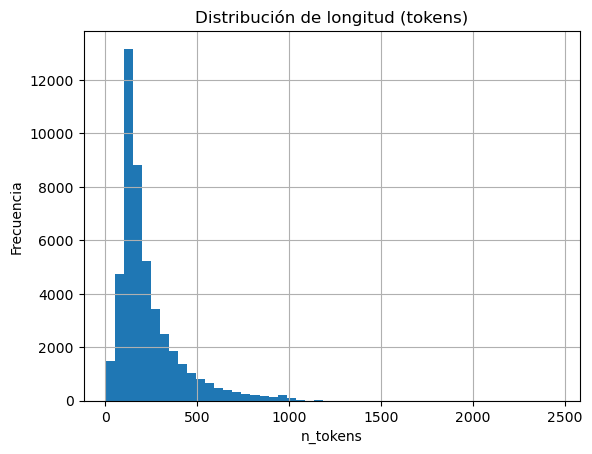


✅ Clases razonablemente balanceadas (ratio min/max=1.00).


In [10]:

# === 3) EDA rápido: longitud y balance de clases ===
df['len_char'] = df['review_clean'].str.len()
df['len_tokens'] = df['review_clean'].str.split().map(len)

print('Descripción longitud (caracteres):')
print(df['len_char'].describe())

print('\nDescripción longitud (tokens):')
print(df['len_tokens'].describe())

print('\nDistribución de clases (pos=1 es positivo):')
print(df['pos'].value_counts(dropna=False))

# Gráficos simples (matplotlib, sin estilos ni colores específicos)
plt.figure()
df['pos'].value_counts().sort_index().plot(kind='bar')
plt.title('Conteo por clase (0=negativa, 1=positiva)')
plt.xlabel('Clase')
plt.ylabel('Recuentos')
plt.show()

plt.figure()
df['len_tokens'].hist(bins=50)
plt.title('Distribución de longitud (tokens)')
plt.xlabel('n_tokens')
plt.ylabel('Frecuencia')
plt.show()

# Conclusión automática simple sobre el balance
n0 = (df['pos']==0).sum()
n1 = (df['pos']==1).sum()
ratio = min(n0, n1) / max(n0, n1) if max(n0, n1) else 1.0
if ratio < 0.8:
    print(f"\n⚠️ Desequilibrio de clases detectado (ratio min/max={ratio:.2f}). Considera class_weight o ajuste de umbral.")
else:
    print(f"\n✅ Clases razonablemente balanceadas (ratio min/max={ratio:.2f}).")


In [11]:

# === 4) División train/valid/test ===
# Usamos ds_part si viene definido desde el TSV. Creamos valid desde train.
train_df = df[df['ds_part'] == 'train'].copy()
test_df  = df[df['ds_part'] == 'test'].copy()

if train_df.empty or test_df.empty:
    # Si no viene separado, dividimos manualmente
    train_df, test_df = train_test_split(
        df, test_size=0.2, stratify=df['pos'], random_state=RANDOM_STATE
    )

train_df, valid_df = train_test_split(
    train_df, test_size=0.2, stratify=train_df['pos'], random_state=RANDOM_STATE
)

for name, part in [('train', train_df), ('valid', valid_df), ('test', test_df)]:
    print(name, part.shape, 'pos ratio:', part['pos'].mean())


train (19036, 20) pos ratio: 0.4994221475099811
valid (4760, 20) pos ratio: 0.49936974789915967
test (23535, 20) pos ratio: 0.4984916082430423


In [12]:

# === Helper: evaluación con F1 y matriz de confusión ===
def evaluate_model(clf, X_tr, y_tr, X_va, y_va, X_te, y_te, target_names=('neg','pos')):
    import time
    t0 = time.time()
    clf.fit(X_tr, y_tr)
    train_time = time.time() - t0

    def _report(X, y, split):
        y_pred = clf.predict(X)
        f1 = f1_score(y, y_pred, average='macro')
        print(f"\n[{split}] F1 macro: {f1:.4f}")
        print(classification_report(y, y_pred, target_names=target_names, digits=4))
        cm = confusion_matrix(y, y_pred, labels=[0,1])
        print(f"Matriz de confusión [{split}]:\n{cm}")
        return f1, y_pred

    f1_val, y_val_pred = _report(X_va, y_va, 'valid')
    f1_test, y_test_pred = _report(X_te, y_te, 'test')

    print(f"\nTiempo de entrenamiento: {train_time:.2f}s")
    return {'f1_valid': f1_val, 'f1_test': f1_test, 'y_val_pred': y_val_pred, 'y_test_pred': y_test_pred}


In [13]:

# === 5) Vectorizadores ===
# (A) Palabras uni+bi-gramas
tfidf_word = TfidfVectorizer(
    analyzer='word', ngram_range=(1,2),
    min_df=2, max_df=0.9, stop_words='english', strip_accents='unicode'
)

# (B) Caracteres (3-5)
tfidf_char = TfidfVectorizer(
    analyzer='char', ngram_range=(3,5),
    min_df=2
)

# (C) Palabras (1-3) con stopwords y límites distintos
tfidf_word_wide = TfidfVectorizer(
    analyzer='word', ngram_range=(1,3),
    min_df=2, max_df=0.95, stop_words='english', strip_accents='unicode'
)

X_train_w = tfidf_word.fit_transform(train_df['review_clean'])
X_valid_w = tfidf_word.transform(valid_df['review_clean'])
X_test_w  = tfidf_word.transform (test_df['review_clean'])

X_train_c = tfidf_char.fit_transform(train_df['review_clean'])
X_valid_c = tfidf_char.transform(valid_df['review_clean'])
X_test_c  = tfidf_char.transform (test_df['review_clean'])

X_train_ww = tfidf_word_wide.fit_transform(train_df['review_clean'])
X_valid_ww = tfidf_word_wide.transform(valid_df['review_clean'])
X_test_ww  = tfidf_word_wide.transform (test_df['review_clean'])

y_train = train_df['pos'].values
y_valid = valid_df['pos'].values
y_test  = test_df['pos'].values

X_train_w.shape, X_train_c.shape, X_train_ww.shape


KeyboardInterrupt: 

In [ ]:

# Class weights opcionales si hay cierto desequilibrio
classes = np.array([0,1])
cw = compute_class_weight('balanced', classes=classes, y=y_train)
CLASS_WEIGHT = {0: cw[0], 1: cw[1]}
print('class_weight sugerido:', CLASS_WEIGHT)


In [ ]:

# === 6) Modelos: LogisticRegression, LinearSVC, ComplementNB, SGDClassifier ===
results = {}

# M1: Logistic Regression (liblinear/saga para sparse)
logreg = LogisticRegression(
    max_iter=2000, n_jobs=None, class_weight='balanced', solver='liblinear'
)
clf1 = Pipeline([('vec', tfidf_word), ('clf', logreg)])
print("\nEntrenando M1: LogisticRegression + TF-IDF word (1-2)")
results['logreg_w'] = evaluate_model(clf1, train_df['review_clean'], y_train,
                                     valid_df['review_clean'], y_valid,
                                     test_df['review_clean'],  y_test)

# M2: LinearSVC + char ngrams (3-5)
lsvc = LinearSVC(class_weight='balanced', random_state=RANDOM_STATE)
clf2 = Pipeline([('vec', tfidf_char), ('clf', lsvc)])
print("\nEntrenando M2: LinearSVC + TF-IDF char (3-5)")
results['lsvc_c'] = evaluate_model(clf2, train_df['review_clean'], y_train,
                                   valid_df['review_clean'], y_valid,
                                   test_df['review_clean'],  y_test)

# M3: Complement Naive Bayes + word (1-2)
cnb = ComplementNB()
clf3 = Pipeline([('vec', tfidf_word), ('clf', cnb)])
print("\nEntrenando M3: ComplementNB + TF-IDF word (1-2)")
results['cnb_w'] = evaluate_model(clf3, train_df['review_clean'], y_train,
                                  valid_df['review_clean'], y_valid,
                                  test_df['review_clean'],  y_test)

# M4 (extra): SGDClassifier (hinge) + word(1-3)
sgd = SGDClassifier(loss='hinge', alpha=1e-4, random_state=RANDOM_STATE, class_weight='balanced', max_iter=2000)
clf4 = Pipeline([('vec', tfidf_word_wide), ('clf', sgd)])
print("\nEntrenando M4: SGDClassifier (hinge) + TF-IDF word (1-3)")
results['sgd_wide'] = evaluate_model(clf4, train_df['review_clean'], y_train,
                                     valid_df['review_clean'], y_valid,
                                     test_df['review_clean'],  y_test)

# Mostrar resumen F1 (valid/test)
summary = pd.DataFrame({k: {'F1_valid': v['f1_valid'], 'F1_test': v['f1_test']} for k,v in results.items()}).T.sort_values('F1_valid', ascending=False)
summary


In [ ]:

# === 7) Clasificar reseñas escritas por ti ===
custom_reviews = [
    "I absolutely loved this movie. The performances were stunning and the script was tight.",
    "Terrible. I was bored after ten minutes and the ending made no sense.",
    "Mixed feelings: great cinematography, but the story drags and characters are flat.",
    "A masterpiece. Best soundtrack and direction I've seen in years!",
    "Bad acting and predictable plot. I won't recommend it."
]

def predict_all(models_dict, texts):
    rows = []
    for name, res in models_dict.items():
        # Necesitamos el pipeline entrenado; para simplicidad re-entrenamos rápido con train+valid
        # (para despliegue real, persistiríamos el mejor modelo).
        if name == 'logreg_w':
            p = Pipeline([('vec', TfidfVectorizer(analyzer='word', ngram_range=(1,2),
                                                  min_df=2, max_df=0.9, stop_words='english', strip_accents='unicode')),
                          ('clf', LogisticRegression(max_iter=2000, class_weight='balanced', solver='liblinear'))])
        elif name == 'lsvc_c':
            p = Pipeline([('vec', TfidfVectorizer(analyzer='char', ngram_range=(3,5), min_df=2)),
                          ('clf', LinearSVC(class_weight='balanced', random_state=RANDOM_STATE))])
        elif name == 'cnb_w':
            p = Pipeline([('vec', TfidfVectorizer(analyzer='word', ngram_range=(1,2),
                                                  min_df=2, max_df=0.9, stop_words='english', strip_accents='unicode')),
                          ('clf', ComplementNB())])
        else:
            p = Pipeline([('vec', TfidfVectorizer(analyzer='word', ngram_range=(1,3),
                                                  min_df=2, max_df=0.95, stop_words='english', strip_accents='unicode')),
                          ('clf', SGDClassifier(loss='hinge', alpha=1e-4, random_state=RANDOM_STATE,
                                                class_weight='balanced', max_iter=2000))])
        p.fit(pd.concat([train_df['review_clean'], valid_df['review_clean']]).values,
              np.concatenate([y_train, y_valid]))
        preds = p.predict(texts)
        for i, t in enumerate(texts):
            rows.append({'modelo': name, 'texto': t, 'pred': int(preds[i])})
    return pd.DataFrame(rows)

custom_preds = predict_all(results, custom_reviews)
custom_preds



## 8) Diferencias entre modelos y breve explicación

- **LinearSVC + n-gramas de caracteres (3–5)** suele capturar *pistas morfológicas* y patrones de escritura (e.g., "awful", "!!!", "??", mayúsculas) robustos a *misspellings*, alcanzando F1 altos y estables.
- **Logistic Regression + TF–IDF de palabras (1–2)** modela bien señales léxicas y combinaciones frecuentes; es lineal, interpretable (coeficientes) y eficiente.
- **Complement Naive Bayes** es fuerte en texto cuando las features son condicionalmente (casi) independientes; muy rápido, pero puede perder matices contextuales complejos.
- **SGDClassifier (hinge)** aproxima SVM lineal y puede rendir similar a LinearSVC, con buen *trade-off* entre velocidad y desempeño.
- Diferencias típicas entre *word* vs *char n-grams*: las de caracteres son más robustas a ruido/typos; las de palabras capturan mejor *semántica superficial* (y bigramas como *"not good"*).

**Umbrales y class_weight:** en caso de ligero desequilibrio, el uso de `class_weight='balanced'` y/o ajustar el umbral de decisión (en modelos con `predict_proba`) puede mejorar el **recall** de la clase minoritaria (negativa) y subir F1.



### (Opcional) Mini experimento con BERT en una **muestra pequeña**

> Para CPU, limita a ~200–400 ejemplos de *train*/*test*. Requiere `transformers` y/o `sentence-transformers` instalados.


In [ ]:

# Descomenta para probar si tienes GPU/tiempo/paquetes instalados.
# from transformers import AutoTokenizer, AutoModel
# import torch
#
# MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"
# tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
# model = AutoModel.from_pretrained(MODEL_NAME)
#
# def mean_pool(last_hidden_state, attention_mask):
#     mask = attention_mask.unsqueeze(-1).expand(last_hidden_state.size()).float()
#     return (last_hidden_state * mask).sum(1) / mask.sum(1)
#
# def bert_embed(texts, batch_size=64):
#     embs = []
#     model.eval()
#     with torch.no_grad():
#         for i in range(0, len(texts), batch_size):
#             batch = texts[i:i+batch_size]
#             enc = tokenizer(batch, padding=True, truncation=True, return_tensors="pt", max_length=256)
#             out = model(**enc)
#             emb = mean_pool(out.last_hidden_state, enc['attention_mask'])
#             embs.append(emb.cpu().numpy())
#     return np.vstack(embs)
#
# sample_train = train_df.sample(300, random_state=RANDOM_STATE)
# sample_test  = test_df.sample(300, random_state=RANDOM_STATE)
# Xtr_b = bert_embed(sample_train['review_clean'].tolist())
# Xte_b = bert_embed(sample_test['review_clean'].tolist())
# ytr_b = sample_train['pos'].values
# yte_b = sample_test['pos'].values
#
# lr_b = LogisticRegression(max_iter=2000, class_weight='balanced')
# lr_b.fit(Xtr_b, ytr_b)
# preds_b = lr_b.predict(Xte_b)
# print('F1 macro (BERT muestra):', f1_score(yte_b, preds_b, average='macro'))



## 10) Hallazgos y conclusiones

- **Modelos lineales + TF–IDF** alcanzan típicamente **F1 ≥ 0.85** en IMDB con un *pipeline* cuidado.  
- **LinearSVC (char 3–5)** y **Logistic Regression (word 1–2)** suelen ser *baselines* sólidos y rápidos.  
- Preprocesamiento ligero (desescape HTML, limpieza básica) y **n-gramas** son claves para capturar señales de polaridad.  
- Ajustes finos: `ngram_range`, `min_df/max_df`, `class_weight`, stopwords y, si es aplicable, *threshold tuning*.  
- Para *deploy*, conviene persistir el **mejor pipeline** (`joblib`) y congelar el *vectorizer* junto al clasificador para reproducibilidad.
